In [1]:
# importing necessary libraries
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
# Reading the CSV file
zomato = pd.read_csv('data.csv')
zomato.head()

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

In [2]:
zomato.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [3]:
zomato.isnull().sum()

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21
rest_type,227


In [4]:
zomato.shape

(51717, 17)

In [5]:
zomato.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [6]:
zomato = zomato.drop(['url', 'address', 'phone', 'dish_liked', 'reviews_list', 'menu_item', 'listed_in(type)'], axis =1)
zomato.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(city)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Banashankari


In [7]:
zomato.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
location,21
rest_type,227
cuisines,45
approx_cost(for two people),346
listed_in(city),0


In [8]:
# duplicate rows check

zomato.duplicated().sum()
# there are rows which are repeated

np.int64(15484)

In [9]:
zomato.drop_duplicates(inplace = True)

In [10]:
zomato.dropna(how = 'any', inplace = True)

In [11]:
zomato.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,0
cuisines,0
approx_cost(for two people),0
listed_in(city),0


In [12]:
zomato.shape

(30201, 10)

In [13]:
# rename two columns
zomato = zomato.rename(columns = {'approx_cost(for two people)': 'cost', 'listed_in(area)':'area'})
zomato.head()

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost,listed_in(city)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,"South Indian, North Indian",300,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,Banashankari


In [14]:
zomato.rate.value_counts()

,count
rate,
NEW,1566
3.9/5,1450
3.7/5,1425
3.8/5,1352
3.9 /5,1314
3.8 /5,1265
3.7 /5,1255
3.6/5,1249
4.0/5,1088


In [15]:
# using lambda function fixing cost and rate columns
zomato = zomato.loc[zomato.rate != 'NEW']
zomato = zomato.loc[zomato.rate != '-']
# it removed all the rows where rate column had 'NEW' and '-'
zomato.shape

(28570, 10)

In [16]:
slash = lambda x:x.replace('/5','')
zomato.rate = zomato.rate.apply(slash).str.strip().astype('float')

In [17]:
zomato.dtypes

,0
name,object
online_order,object
book_table,object
rate,float64
votes,int64
location,object
rest_type,object
cuisines,object
cost,object
listed_in(city),object


In [18]:
zomato.cost.value_counts()

,count
cost,
300,3866
400,3835
500,2883
200,2444
600,2198
250,1598
800,1315
700,1137
150,1042


In [19]:
zomato.cost = zomato.cost.astype(str)
zomato.cost = zomato.cost.apply(lambda x:x.replace(',',''))
zomato.cost = zomato.cost.astype(float)


In [20]:
zomato.cost.dtype

dtype('float64')

In [21]:
zomato.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28570 entries, 0 to 51677
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             28570 non-null  object 
 1   online_order     28570 non-null  object 
 2   book_table       28570 non-null  object 
 3   rate             28570 non-null  float64
 4   votes            28570 non-null  int64  
 5   location         28570 non-null  object 
 6   rest_type        28570 non-null  object 
 7   cuisines         28570 non-null  object 
 8   cost             28570 non-null  float64
 9   listed_in(city)  28570 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 2.4+ MB


In [22]:
zomato.online_order.value_counts()


,count
online_order,
Yes,19169
No,9401


In [23]:
zomato.online_order.replace(('Yes','No'), (1,0), inplace = True)
zomato.book_table.replace(('Yes','No'), (1,0), inplace = True)

In [24]:
zomato.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28570 entries, 0 to 51677
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             28570 non-null  object 
 1   online_order     28570 non-null  int64  
 2   book_table       28570 non-null  int64  
 3   rate             28570 non-null  float64
 4   votes            28570 non-null  int64  
 5   location         28570 non-null  object 
 6   rest_type        28570 non-null  object 
 7   cuisines         28570 non-null  object 
 8   cost             28570 non-null  float64
 9   listed_in(city)  28570 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 2.4+ MB


In [25]:
zomato['listed_in(city)'].value_counts()

,count
listed_in(city),
Koramangala 4th Block,2063
BTM,1816
Jayanagar,1786
Koramangala 7th Block,1680
Koramangala 5th Block,1509
Koramangala 6th Block,1492
JP Nagar,1084
MG Road,985
Brigade Road,939


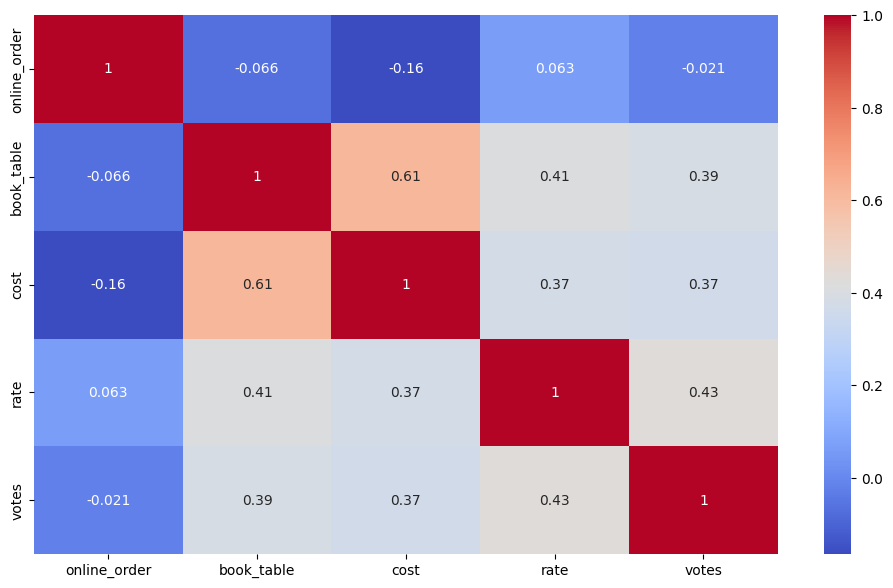

In [26]:
zomato1 = zomato[['online_order','book_table','cost','rate','votes']]
corr = zomato1.corr()
plt.figure(figsize = (12,7))
sns.heatmap(corr , annot = True, cmap = 'coolwarm')
plt.show()

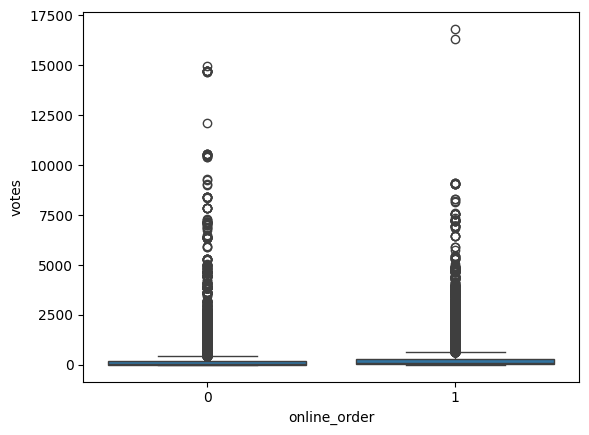

In [27]:
#  analyze for cost and votes column

sns.boxplot(data = zomato1, x = 'online_order', y = 'votes')
plt.show()

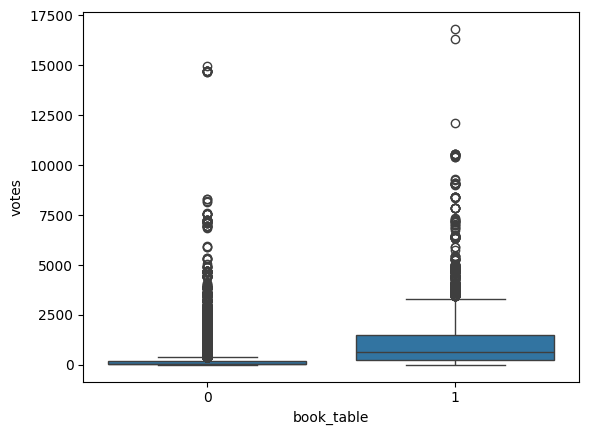

In [28]:
sns.boxplot(data = zomato1, x = 'book_table', y = 'votes')
plt.show()

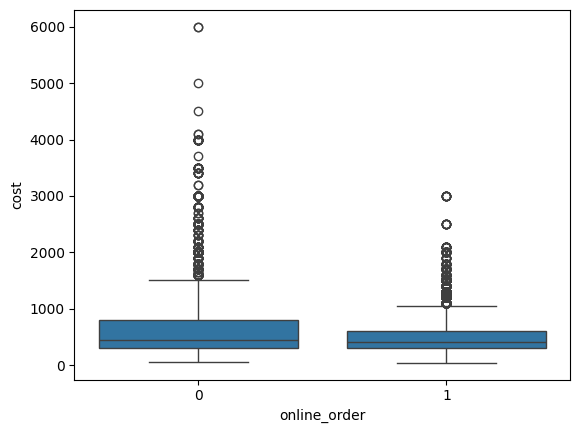

In [29]:
sns.boxplot(data = zomato1, x = 'online_order', y = 'cost')
plt.show()

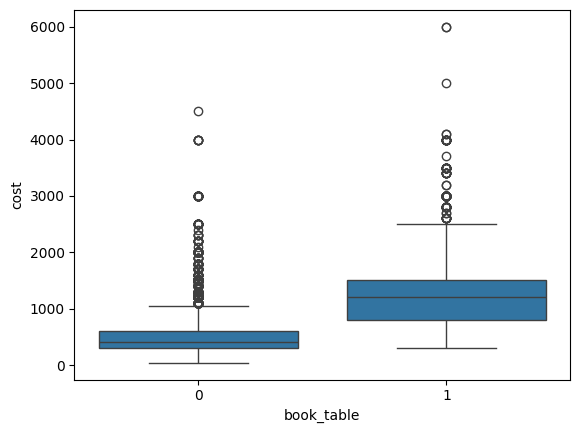

In [30]:
sns.boxplot(data = zomato1, x = 'book_table', y = 'cost')
plt.show()

In [31]:
zomato1.describe()

,online_order,book_table,cost,rate,votes
count,28570.000000,28570.000000,28570.000000,28570.000000,28570.000000
mean,0.670949,0.129436,567.539587,3.685761,320.629786
std,0.469877,0.335688,451.257991,0.436315,824.711703
min,0.000000,0.000000,40.000000,1.800000,0.000000
25%,0.000000,0.000000,300.000000,3.400000,19.000000
50%,1.000000,0.000000,400.000000,3.700000,67.000000
75%,1.000000,0.000000,700.000000,4.000000,247.000000
max,1.000000,1.000000,6000.000000,4.900000,16832.000000


In [32]:
from sklearn.model_selection import train_test_split
X = zomato1.drop(['cost'], axis =1)
y = zomato1['cost']
X_train, X_test, y_train, y_test = train_test_split(X, y , random_state = 100, test_size = 0.2)

In [33]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(min_samples_leaf = 5)
dt.fit(X_train, y_train)

DecisionTreeRegressor(min_samples_leaf=5)

In [34]:
y_train_pred = dt.predict(X_train)

In [35]:
from sklearn.metrics import r2_score
r2_score(y_train, y_train_pred)

0.7539727836832399

In [36]:
y_test_pred = dt.predict(X_test)
r2_score(y_test, y_test_pred)

0.5932391138735518

In [37]:
from sklearn.model_selection import GridSearchCV
dt = DecisionTreeRegressor()
params = {'max_depth':[2,3,4,10,20,30,35,50],
          'min_samples_leaf':[5,10,20,30,40,50,100],
          'min_samples_split':[5,10,20,30,40,50,100],
          'criterion':['squared_error', 'absolute_error','friedman_mse','poisson']}

In [38]:
gridsearch = GridSearchCV(estimator = dt,
                         param_grid = params,
                         cv = 5,
                         n_jobs = -1,
                         scoring = 'r2')

In [ ]:
gridsearch.fit(X_train, y_train)

In [ ]:
gridsearch.best_params_

In [ ]:
best_model = gridsearch.best_estimator_
best_model

In [ ]:
y_train_pred = best_model.predict(X_train)
r2_score(y_train, y_train_pred)

In [ ]:
y_test_pred = best_model.predict(X_test)
r2_score(y_test, y_test_pred)

In [ ]:
from IPython.display import Image
from six import StringIO
from sklearn.tree import export_graphviz
import pydotplus, graphviz

In [ ]:
dot_data = StringIO()
export_graphviz(best_model, out_file = dot_data, filled = True,
               rounded = True, feature_names = X_train.columns)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(max_depth = 4, min_samples_leaf=10, min_samples_split=5,criterion='absolute_error')
rf.fit(X_train, y_train)

In [ ]:
y_predicted = rf.predict(X_train)
r2_score(y_train, y_predicted)

In [ ]:
y_test_predicted = rf.predict(X_test)
r2_score(y_test, y_test_predicted)

In [ ]:
sample_tree = rf.estimators_[20]
dot_data = StringIO()
export_graphviz(sample_tree, out_file = dot_data, filled = True, rounded = True, feature_names = X_train.columns)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

In [ ]:
rf.feature_importances_

In [ ]:
Imp_df=pd.DataFrame({'Varname':X_train.columns, 'Imp':rf.feature_importances_})
Imp_df.sort_values(by = 'Imp', ascending = False)

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
et = ExtraTreesRegressor(n_estimators = 500, random_state = 300, min_samples_leaf = 0.0001)
et.fit(X_train, y_train)

In [ ]:
y_predicted = et.predict(X_train)
r2_score(y_train, y_predicted)

In [ ]:
y_test_predicted = et.predict(X_test)
r2_score(y_test, y_test_predicted)